In [4]:
!rm -rf ~/.kaggle

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n" username ": ricardosapakoly,\r\n" apikey ": KGAT_ef0d179d3bd23440e1706b1535a33b75\r\n}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!cat ~/.kaggle/kaggle.json

{
" username ": ricardosapakoly,
" apikey ": KGAT_ef0d179d3bd23440e1706b1535a33b75
}

In [8]:
!kaggle datasets list


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 675, in authenticate
    if self._authenticate_with_legacy_apikey():
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 720, in _authenticate_with_legacy_apikey
    raise ValueError("Error: Missing %s in configuration." % item)
ValueError: Error: Missing username in configuration.


In [9]:
import os

os.environ['KAGGLE_USERNAME'] = 'ricardosapakoly'
os.environ['KAGGLE_KEY'] = 'KGAT_ef0d179d3bd23440e1706b1535a33b75'

In [10]:
!kaggle datasets list

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                              Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          11485        248                1  
nalisha/job-salary-prediction-dataset                       Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          15136        331                1  
mubashirsidiki/student-academic-performance-500-students    Student Academic Performance - 500 Students               6413  2026-04-07 14:23:47.547000           2941         63                1  
arfeenkabir/customer

In [11]:
!kaggle datasets download -d prasunroy/natural-images

Dataset URL: https://www.kaggle.com/datasets/prasunroy/natural-images
License(s): CC-BY-NC-SA-4.0
100% 342M/342M [00:01<00:00, 183MB/s]



In [12]:
!unzip natural-images.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: natural_images/cat/cat_0204.jpg  
  inflating: natural_images/cat/cat_0205.jpg  
  inflating: natural_images/cat/cat_0206.jpg  
  inflating: natural_images/cat/cat_0207.jpg  
  inflating: natural_images/cat/cat_0208.jpg  
  inflating: natural_images/cat/cat_0209.jpg  
  inflating: natural_images/cat/cat_0210.jpg  
  inflating: natural_images/cat/cat_0211.jpg  
  inflating: natural_images/cat/cat_0212.jpg  
  inflating: natural_images/cat/cat_0213.jpg  
  inflating: natural_images/cat/cat_0214.jpg  
  inflating: natural_images/cat/cat_0215.jpg  
  inflating: natural_images/cat/cat_0216.jpg  
  inflating: natural_images/cat/cat_0217.jpg  
  inflating: natural_images/cat/cat_0218.jpg  
  inflating: natural_images/cat/cat_0219.jpg  
  inflating: natural_images/cat/cat_0220.jpg  
  inflating: natural_images/cat/cat_0221.jpg  
  inflating: natural_images/cat/cat_0222.jpg  
  inflating: natural_images/cat/cat_0223.jpg  
 

In [13]:
import os
os.listdir()

['.config',
 'data',
 'kaggle.json',
 'natural-images.zip',
 'natural_images',
 'sample_data']

In [14]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'natural_images',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'natural_images',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 6899 files belonging to 8 classes.
Using 5520 files for training.
Found 6899 files belonging to 8 classes.
Using 1379 files for validation.


In [15]:
class_names = train_ds.class_names
print(class_names)

['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


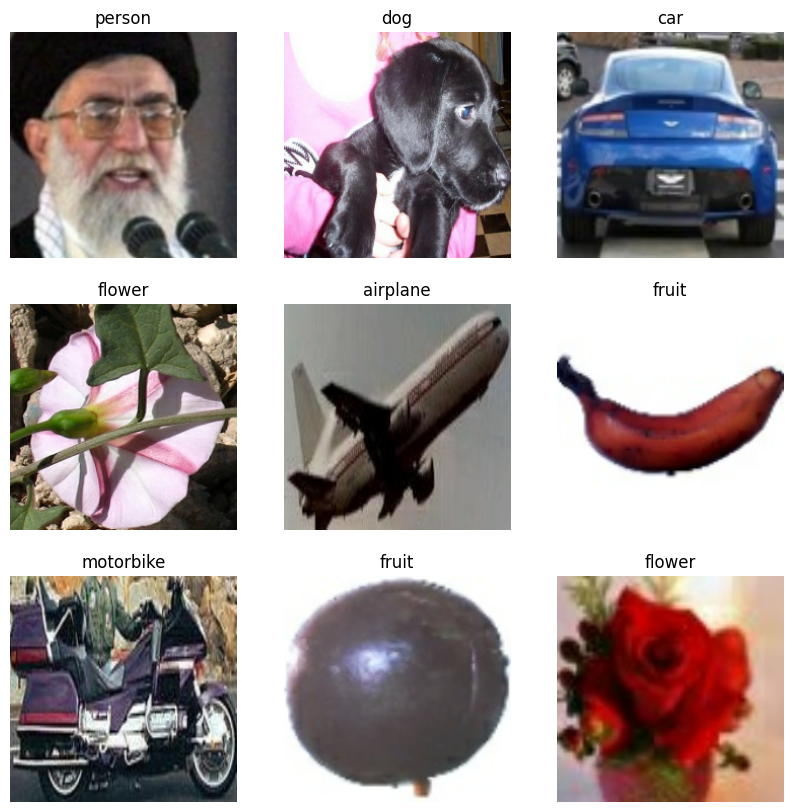

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [18]:
from tensorflow.keras import layers, models

In [19]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [20]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [25]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 70s 236ms/step - accuracy: 0.9786 - loss: 0.1064 - val_accuracy: 0.9964 - val_loss: 0.0092
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9993 - loss: 0.0057 - val_accuracy: 0.9985 - val_loss: 0.0033
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0023
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9978 - val_loss: 0.0039
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9978 - val_loss: 0.0044
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9985 - val_loss: 0.0022
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9993 - val_loss: 0.0012
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9998 - loss: 6.7512e-04 - 

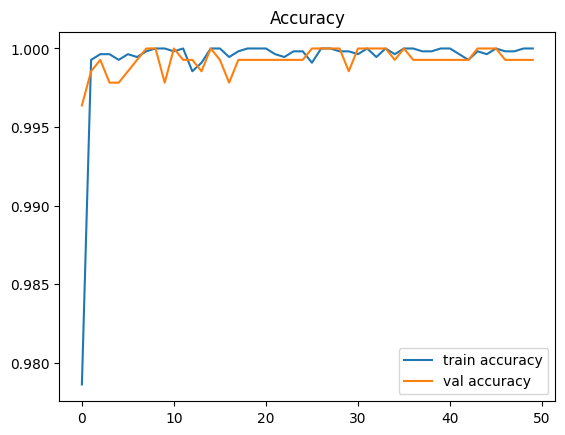

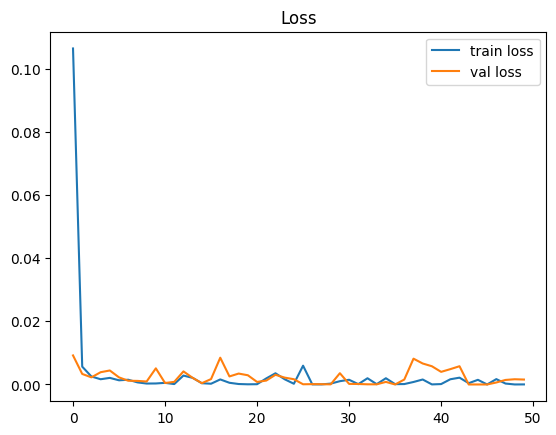

In [27]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [28]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9993 - loss: 0.0016
Validation Accuracy: 0.9992748498916626


In [29]:
import numpy as np

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    print("Prediksi:", class_names[np.argmax(preds[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediksi: person


In [30]:
import numpy as np
import tensorflow as tf

last_conv_layer = base_model.layers[-1].name

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap.numpy()

In [31]:
import numpy as np

for images, labels in val_ds.take(1):
    img = images[0]
    img_array = np.expand_dims(img, axis=0)
    break

In [35]:
last_conv_layer_name = base_model.layers[-1].name
print(last_conv_layer_name)

top_activation


In [40]:
last_conv_layer = base_model.get_layer(last_conv_layer_name)

In [43]:
_ = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [47]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model(base_model.input)
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [48]:
heatmap = make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name)

ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

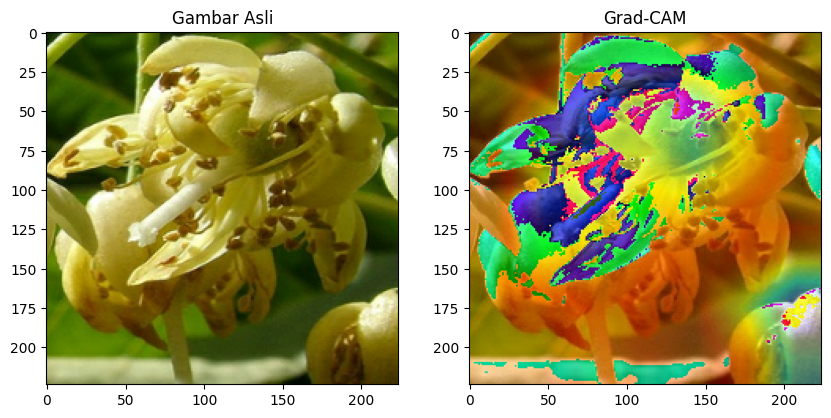

In [50]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# 1. Ambil 1 gambar
for images, labels in val_ds.take(1):
    img = images[0]
    img_array = np.expand_dims(img, axis=0)
    break

# 2. Ambil layer conv terakhir
last_conv_layer = base_model.get_layer("top_conv")

# 3. Buat model baru (ini kunci utama 🔥)
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, outputs]
)

# 4. Hitung Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    loss = predictions[:, pred_index]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

# 5. Tampilkan hasil
img = img.numpy().astype("uint8")
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Gambar Asli")

plt.subplot(1,2,2)
plt.imshow(superimposed_img.astype("uint8"))
plt.title("Grad-CAM")

plt.show()